In [3]:
import os
import yaml
import torch
from ultralytics import RTDETR

print("=== Fresh RT-DETR-L Setup ===")
print(f"GPU Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

DATASET_ROOT = r"C:\Users\HP\Desktop\Anamoly_Dataset2"
YOLO_DS_PATH = os.path.join(DATASET_ROOT, "yolov8_dataset")
yaml_path    = os.path.join(YOLO_DS_PATH, "data.yaml")

=== Fresh RT-DETR-L Setup ===
GPU Available: True
GPU: NVIDIA GeForce RTX 5050 Laptop GPU


In [9]:
import os
import shutil
import random
import xml.etree.ElementTree as ET
from pathlib import Path
from collections import defaultdict

DATASET_ROOT = r"C:\Users\HP\Desktop\Anamoly_Dataset2"

RAW_IMAGES_PATH = os.path.join(DATASET_ROOT, "images")
RAW_LABELS_PATH = os.path.join(DATASET_ROOT, "labels")
YOLO_DS_PATH    = os.path.join(DATASET_ROOT, "yolov8_dataset")

print("Starting fresh dataset rebuild...")

RAW_TO_ENGLISH = {
    '1_chongkong': 'punching_hole',
    '2_hanfeng': 'welding_line',
    '3_yueyawan': 'crescent_gap',
    '4_shuiban': 'water_spot',
    '5_youban': 'oil_spot',
    '6_siban': 'silk_spot',
    '7_yiwu': 'inclusion',
    '8_yahen': 'dent',
    '9_zhehen': 'rolled_pit',
    '10_yaozhed': 'waist_folding',
}

CLASS_NAMES = sorted(set(RAW_TO_ENGLISH.values()))
CLASS_TO_ID = {name: i for i, name in enumerate(CLASS_NAMES)}

for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(YOLO_DS_PATH, 'images', split), exist_ok=True)
    os.makedirs(os.path.join(YOLO_DS_PATH, 'labels', split), exist_ok=True)

img_map = {}
for root, _, files in os.walk(RAW_IMAGES_PATH):
    for f in files:
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_map[f] = os.path.join(root, f)

print(f"Found {len(img_map)} raw images")


# Parse XML labels
img_labels = defaultdict(list)

xml_files = []
for root, _, files in os.walk(RAW_LABELS_PATH):
    for f in files:
        if f.endswith('.xml'):
            xml_files.append(os.path.join(root, f))

print(f"Parsing {len(xml_files)} XML files...")

for xf in xml_files:
    try:
        tree = ET.parse(xf)
        root = tree.getroot()
        filename = root.find('filename').text if root.find('filename') is not None else None
        size = root.find('size')
        iw = int(size.find('width').text) if size is not None else None
        ih = int(size.find('height').text) if size is not None else None

        for obj in root.findall('object'):
            name_raw = obj.find('name').text.strip()
            if name_raw in RAW_TO_ENGLISH:
                cls_id = CLASS_TO_ID[RAW_TO_ENGLISH[name_raw]]
                bndbox = obj.find('bndbox')
                xmin = int(float(bndbox.find('xmin').text))
                ymin = int(float(bndbox.find('ymin').text))
                xmax = int(float(bndbox.find('xmax').text))
                ymax = int(float(bndbox.find('ymax').text))

                if iw and ih:
                    xc = ((xmin + xmax) / 2) / iw
                    yc = ((ymin + ymax) / 2) / ih
                    w = (xmax - xmin) / iw
                    h = (ymax - ymin) / ih
                    img_labels[filename].append((cls_id, xc, yc, w, h))
    except:
        continue

valid_imgs = [fn for fn in img_labels if fn in img_map]
random.shuffle(valid_imgs)

n = len(valid_imgs)
n_train = int(n * 0.7)
n_val   = int(n * 0.2)

train_imgs = valid_imgs[:n_train]
val_imgs   = valid_imgs[n_train:n_train+n_val]
test_imgs  = valid_imgs[n_train+n_val:]

print(f"Split → Train: {len(train_imgs)} | Val: {len(val_imgs)} | Test: {len(test_imgs)}")


for imgs, split in zip([train_imgs, val_imgs, test_imgs], ['train', 'val', 'test']):
    for img_fn in imgs:
        src = img_map[img_fn]
        dst = os.path.join(YOLO_DS_PATH, 'images', split, img_fn)
        shutil.copy2(src, dst)

        # Create label txt
        stem = Path(img_fn).stem
        lbl_path = os.path.join(YOLO_DS_PATH, 'labels', split, stem + '.txt')
        with open(lbl_path, 'w') as f:
            for cls_id, xc, yc, w, h in img_labels[img_fn]:
                f.write(f"{cls_id} {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}\n")

print(" Dataset rebuilt successfully!")
print(f"Location: {YOLO_DS_PATH}")

Starting fresh dataset rebuild...
Found 3802 raw images
Parsing 3802 XML files...
Split → Train: 2661 | Val: 760 | Test: 381
✅ Dataset rebuilt successfully!
Location: C:\Users\HP\Desktop\Anamoly_Dataset2\yolov8_dataset


# Training the Real-Time Detection Transformer Algorithm

In [10]:
from ultralytics import RTDETR
import os

DATASET_ROOT = r"C:\Users\HP\Desktop\Anamoly_Dataset2"
YOLO_DS_PATH = os.path.join(DATASET_ROOT, "yolov8_dataset")
yaml_path = os.path.join(YOLO_DS_PATH, "data.yaml")

model = RTDETR("rtdetr-l.pt")

print("Starting RT-DETR-L Training...\n")
print("Estimated time: 8 to 14 hours. Keep laptop plugged in and ventilated.")

results = model.train(
    data          = yaml_path,
    epochs        = 60,          
    imgsz         = 640,
    batch         = 6,           
    device        = 0,
    patience      = 20,
    optimizer     = 'AdamW',
    lr0           = 0.001,
    weight_decay  = 0.0005,
    workers       = 4,
    
    hsv_h         = 0.0,
    hsv_s         = 0.0,
    hsv_v         = 0.5,
    degrees       = 8.0,
    translate     = 0.1,
    scale         = 0.5,
    fliplr        = 0.5,
    mosaic        = 1.0,
    
    project       = os.path.join(DATASET_ROOT, "runs"),
    name          = "rtdetr_l_steel_defect",
    exist_ok      = True,
    verbose       = True,
    plots         = True
)

print("\nRT-DETR-L Training Completed!")
print(f"Best model saved at: {results.save_dir}/weights/best.pt")

🚀 Starting RT-DETR-L Training...

Estimated time: 8 to 14 hours. Keep laptop plugged in and ventilated.
Ultralytics 8.4.37  Python-3.11.15 torch-2.12.0.dev20260408+cu128 CUDA:0 (NVIDIA GeForce RTX 5050 Laptop GPU, 8151MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=6, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\HP\Desktop\Anamoly_Dataset2\yolov8_dataset\data.yaml, degrees=8.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.5, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, mode

C:\Users\HP\.conda\envs\steel_defect\Lib\site-packages\torch\autograd\graph.py:882: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\Context.cpp:164.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/60      5.09G      1.154      1.727      0.853          7        640: 100% ━━━━━━━━━━━━ 444/444 1.0s/it 7:30<1.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 64/64 2.5it/s 25.2s0.3ss
                   all        760       1200      0.678      0.146     0.0337       0.01

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


C:\Users\HP\.conda\envs\steel_defect\Lib\site-packages\torch\autograd\graph.py:882: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\Context.cpp:164.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/60      5.25G      0.739      1.349     0.4696          7        640: 100% ━━━━━━━━━━━━ 444/444 1.1it/s 6:56<0.9s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 64/64 3.3it/s 19.2s0.3s
                   all        760       1200      0.129      0.391      0.065     0.0259

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       3/60      5.21G     0.7598      1.172     0.4028         23        640: 0% ──────────── 0/444  1.0s

...

      58/60      5.25G     0.4395     0.6315     0.3059          4        640: 100% ━━━━━━━━━━━━ 444/444 1.1it/s 6:51<0.9s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 64/64 3.3it/s 19.4s0.3s
                   all        760       1200      0.771      0.721      0.725      0.354

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      59/60      5.22G     0.4029     0.4518     0.2041          7        640: 0% ──────────── 0/444  1.0s

C:\Users\HP\.conda\envs\steel_defect\Lib\site-packages\torch\autograd\graph.py:882: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\Context.cpp:164.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      59/60      5.25G     0.4404     0.6001     0.3034          2        640: 100% ━━━━━━━━━━━━ 444/444 1.1it/s 6:51<0.9s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 64/64 3.3it/s 19.4s0.3s
                   all        760       1200       0.76      0.707      0.724      0.366

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


C:\Users\HP\.conda\envs\steel_defect\Lib\site-packages\torch\autograd\graph.py:882: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\Context.cpp:164.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      60/60      5.25G     0.4403      0.602     0.3038          2        640: 100% ━━━━━━━━━━━━ 444/444 1.1it/s 6:53<0.9s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 64/64 3.3it/s 19.4s0.3s
                   all        760       1200      0.755      0.714      0.731      0.371

60 epochs completed in 7.281 hours.
Optimizer stripped from C:\Users\HP\Desktop\Anamoly_Dataset2\runs\rtdetr_l_steel_defect\weights\last.pt, 66.3MB
Optimizer stripped from C:\Users\HP\Desktop\Anamoly_Dataset2\runs\rtdetr_l_steel_defect\weights\best.pt, 66.3MB

Validating C:\Users\HP\Desktop\Anamoly_Dataset2\runs\rtdetr_l_steel_defect\weights\best.pt...
Ultralytics 8.4.37  Python-3.11.15 torch-2.12.0.dev20260408+cu128 CUDA:0 (NVIDIA GeForce RTX 5050 Laptop GPU, 8151MiB)
rt-detr-l summary: 310 layers, 32,004,290 parameters, 0 gradients, 103.5 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━

# Testing model

Model loaded successfully!


image 1/1 C:\Users\Gaurav\OneDrive\Desktop\projects\Surface_anamoly_detection\Anamoly_Dataset\yolov8_dataset\images\test\img_02_425622400_00001.jpg: 640x640 1 crescent_gap, 1 punching_hole, 1 welding_line, 4607.2ms
Speed: 10.4ms preprocess, 4607.2ms inference, 6.5ms postprocess per image at shape (1, 3, 640, 640)


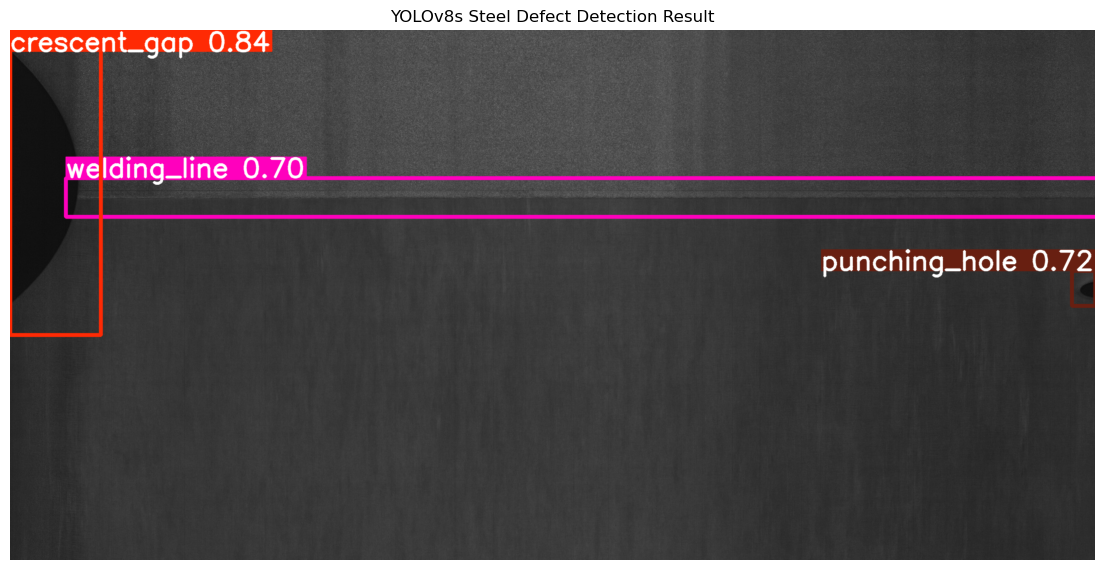

Detected Defects:


NameError: name 'CLASS_NAMES' is not defined

In [2]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import os

best_pt = r"C:\Users\Gaurav\OneDrive\Desktop\projects\Surface_anamoly_detection\Trained_Models\rtdetr_l_best.pt"


if not os.path.exists(best_pt):
    print(f"Model not found at:\n{best_pt}")
    print("Please verify the path and filename.")
else:
    model = YOLO(best_pt)
    print("Model loaded successfully!\n")

    test_image = r"C:\Users\Gaurav\OneDrive\Desktop\projects\Surface_anamoly_detection\Anamoly_Dataset\yolov8_dataset\images\test\img_02_425622400_00001.jpg"

    if os.path.exists(test_image):
        results = model.predict(
            test_image, 
            conf=0.25,     
            iou=0.45,     
            save=False
        )
        
        plotted_img = results[0].plot()
        plt.figure(figsize=(14, 10))
        plt.imshow(plotted_img)
        plt.axis('off')
        plt.title("YOLOv8s Steel Defect Detection Result")
        plt.show()
        
        print("Detected Defects:")
        for box in results[0].boxes:
            cls_id = int(box.cls)
            conf = float(box.conf)
            print(f"→ {CLASS_NAMES[cls_id]:15s} : {conf:.1%} confidence")
            
    else:
        print("Test image not found. Please check the test_image path.")

![F1 Curve](C:/Users/Gaurav/OneDrive/Desktop/projects/Surface_anamoly_detection/rtdetr_l_steel_defect/BoxF1_curve.png)


![Labels](C:/Users/Gaurav/OneDrive/Desktop/projects/Surface_anamoly_detection/rtdetr_l_steel_defect/labels.jpg)


![Confusion Matrix](C:/Users/Gaurav/OneDrive/Desktop/projects/Surface_anamoly_detection/rtdetr_l_steel_defect/confusion_matrix_normalized.png)